=== STEP 1: LOADING DATASET ===
Dataset shape after removing NaNs: (155, 6)

=== STEP 2: PREPROCESSING & SCALING ===

=== STEP 3: TRAINING MODELS ===

=== STEP 4: EVALUATION METRICS ===
--- Logistic Regression ---
Accuracy:  0.6452
Precision: 0.6364
Recall:    0.8235
F1 Score:  0.7179

--- Decision Tree ---
Accuracy:  0.7097
Precision: 0.7000
Recall:    0.8235
F1 Score:  0.7568

=== STEP 5: GENERATING VISUALIZATIONS ===


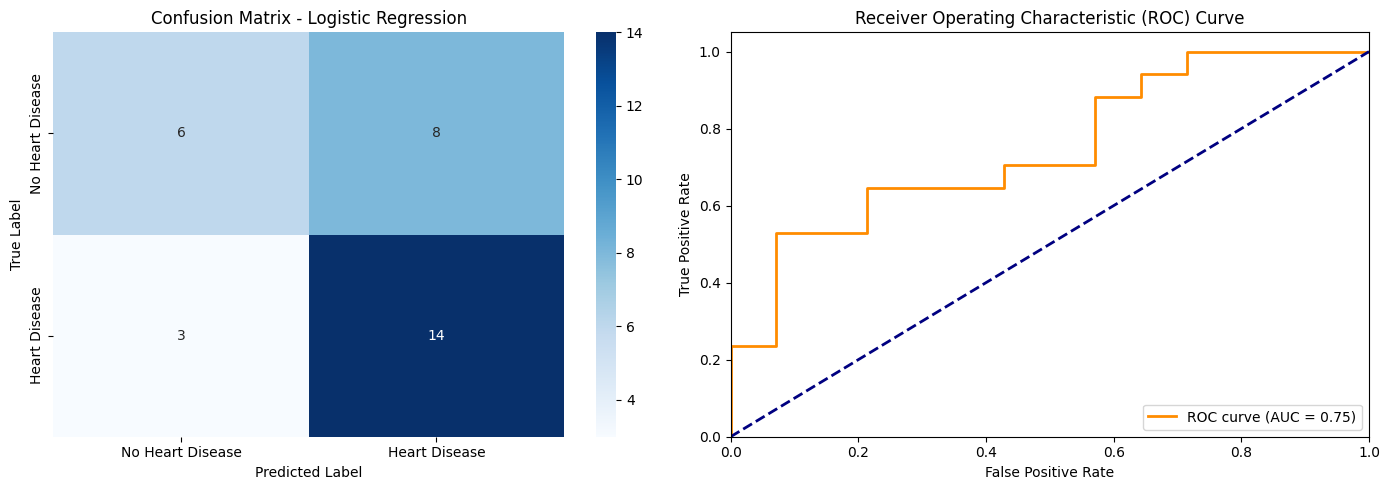

[SUCCESS] Capstone Project completed!


In [1]:
# =====================================================================
# MACHINE LEARNING & AI - WEEK 4 CAPSTONE PROJECT
# OPTION 1: HEART DISEASE PREDICTION
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# ---------------------------------------------------------------------
# STEP 1: DATA LOADING & EXPLORATION
# ---------------------------------------------------------------------
print("=== STEP 1: LOADING DATASET ===")

# UCI Heart Disease Dataset URL
url = "https://raw.githubusercontent.com/pmarcelino/datasets/master/heart.csv"
df = pd.read_csv(url)

# FIX: Clean missing values across features and target
df = df.dropna()

print(f"Dataset shape after removing NaNs: {df.shape}")

# ---------------------------------------------------------------------
# STEP 2: DATA PREPROCESSING & FEATURE SCALING
# ---------------------------------------------------------------------
print("\n=== STEP 2: PREPROCESSING & SCALING ===")

# Features (X) and Target (y)
X = df.drop(columns=['target'])
y = df['target']

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------------------
# STEP 3: MODEL TRAINING (LOGISTIC REGRESSION & DECISION TREE)
# ---------------------------------------------------------------------
print("\n=== STEP 3: TRAINING MODELS ===")

# Model 1: Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model 2: Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_classifier.fit(X_train, y_train)

# ---------------------------------------------------------------------
# STEP 4: MODEL EVALUATION & METRICS
# ---------------------------------------------------------------------
print("\n=== STEP 4: EVALUATION METRICS ===")

def evaluate_model(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_t, y_pred)
    prec = precision_score(y_t, y_pred)
    rec = recall_score(y_t, y_pred)
    f1 = f1_score(y_t, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")
    return y_pred

y_pred_lr = evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test)
y_pred_dt = evaluate_model("Decision Tree", dt_classifier, X_test, y_test)

# ---------------------------------------------------------------------
# STEP 5: VISUALIZATIONS (CONFUSION MATRIX & ROC CURVE)
# ---------------------------------------------------------------------
print("=== STEP 5: GENERATING VISUALIZATIONS ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Plot for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. ROC Curve Plot
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("[SUCCESS] Capstone Project completed!")